<div>
<img src="https://drive.google.com/uc?export=view&id=1vK33e_EqaHgBHcbRV_m38hx6IkG0blK_" width="350"/>
</div> 


## ET5003  Machine Learning Applications
## SEM1 2025/2026

### ET5003 Assignment #1 - Data Preprocessing and Training a Machine Learning Model

### Instructor: Emil Vassev
Sept 13th, 2022; Sept 16th, 2025
<br><br>
Copyright (C) 2025 - All rights reserved, do not copy or distribute without permission of the author.
***

## Submission Info
### Student Name: <span style="color:red">David</span>
### Student Surname: <span style="color:red">Sheridan</span>
### Student ID: <span style="color:red">24300446</span>
### Date of Final Submission: <span style="color:red">05/10/2025</span>
***

## Introduction
Real-world datasets for ML are expected to be *incomplete*, *inconsistent*, and *noisy* due to their heterogeneous origin. Applying ML algorithms on such data would not give quality results as they would fail to identify patterns effectively.

**Data Preprocessing** is a part of the ML process, which strives to improve the overall data quality by dealing with:
* duplicate or missing values - such data may give an incorrect view of the overall statistics of data;
* outliers and inconsistent data points - such data often tend to disturb the model’s overall learning and thus, leading to false predictions.

Data Preprocessing targets ML features, which are:
* individual independent variables operating as inputs to ML models;
* representations or attributes that describe the data and help the models to predict the classes/labels.

Example: features in a structured dataset (e.g., in a CSV format) refer to each column representing a measurable piece of data that can be used for analysis: name, age, sex, fare, etc.

**Model Training** is a primary step in ML in which a ML algorithm is fed with sufficient training data to learn from. Model Training results in a working ML model that can then be validated, tested and deployed.

## Task
In this assignment, you are asked to follow the ML process to:
* preprocess a provided dataset, so it will become suitable for ML operations;
* select an appropriate ML model, so it will cope with the specifics of data and ML tasks;
* train the selected ML model on the preprocessed dataset;
* test the selected ML model on the preprocessed dataset. 

Please, consult the lectures of weeks #1 and #2 for the specifics of the different ML models, the Data Preprocessing staeps and the specifics of Model Training and Testing.

## The Dataset
The provided dataset covers bond trading operations (buy and sell) on a financial market. The data is labeled and provided in its raw format, so it needs to be preprocessed.   

The provided dataset can be loaded as following:

In [56]:
import pandas as pd

url_dataset = "https://raw.githubusercontent.com/evassev/ET5003_SEM1_2022/main/Etivities/data/trade_combined.csv"
df = pd.read_csv(url_dataset)

df.head(10)

,NoRelatedSym,Symbol,SymbolSfx,SecurityID,SecurityIDSource,SecurityType,MaturityDate,IssueDate,Side,OrderQty,...,NoPartIDs,PartyID,DealerID,DealerTraderID,CustomerTraderID,CustomerID,PartyIDSource,PartyRole,DealerCount,OrdSubType
0,1,135087L93,WI,NaN,1,BOND,9/1/2026,4/16/2021 0:00,BUY,2400000,...,1,1,334,10792.0,6549,129,D,13,5,OUTRIGHT
1,1,135087L93,WI,NaN,1,BOND,9/1/2026,4/16/2021 0:00,BUY,2400000,...,1,1,335,117793.0,6549,129,D,13,5,OUTRIGHT
2,1,135087L93,WI,NaN,1,BOND,9/1/2026,4/16/2021 0:00,BUY,2400000,...,1,1,325,119290.0,6549,129,D,13,5,OUTRIGHT
3,1,135087L93,WI,NaN,1,BOND,9/1/2026,4/16/2021 0:00,BUY,2400000,...,1,1,327,113852.0,6549,129,D,13,5,OUTRIGHT
4,1,135087L93,WI,NaN,1,BOND,9/1/2026,4/16/2021 0:00,BUY,2400000,...,1,1,337,117795.0,6549,129,D,13,5,OUTRIGHT
5,1,135087M76,WI,NaN,1,BOND,11/1/2023,8/9/2021 0:00,SELL,15000000,...,1,1,325,119752.0,7019,277,D,13,4,OUTRIGHT
6,1,135087M76,WI,NaN,1,BOND,11/1/2023,8/9/2021 0:00,SELL,15000000,...,1,1,336,117794.0,7019,277,D,13,4,OUTRIGHT
7,1,135087M76,WI,NaN,1,BOND,11/1/2023,8/9/2021 0:00,SELL,15000000,...,1,1,323,117786.0,7019,277,D,13,4,OUTRIGHT
8,1,135087M76,WI,NaN,1,BOND,11/1/2023,8/9/2021 0:00,SELL,15000000,...,1,1,337,117795.0,7019,277,D,13,4,OUTRIGHT
9,1,135087L93,WI,NaN,1,BOND,9/1/2026,4/16/2021 0:00,SELL,600000,...,1,1,335,117793.0,11532,177,D,13,4,OUTRIGHT


## Target: In this task you are asked to predict the  <span style="color:red">Bond Price</span>.

## Note: In the following steps use the dataframe object <span style="color:red">df</span>.  

## Here are the steps you need to follow:

# Step 1: Determine the ML Model: Supervised-Classification, Supervised-Regression, or Unsupervised ML Model.  (5%)

Goal: to predict the bond price using various features (such as trade details, bond attributes, and dealer information).

Analysis: the dataset contains both independent variables and a dependent vartiable (bond price) that we want to predict. 
Since the target variable, bond price, is numeric and continuous, our task is to estimate a real-valued outcome based on the input features.

Model Type Decision:
Type: Supervised - Regression
Description: Predicts continuous numeric values
Target Variable Type: Continuous

I found supervised - classification and unsupervised learning to be not so suitable for this task.

Conclusion:
This is a supervised learning - regression problem.
I will use regression models, such as linear regression, random forest regressor, or gradient boosting regressor, to learn the relationship between trade features and the bond price.



# Step 2: Data Preprocessing.  (45%)

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
url_dataset = "https://raw.githubusercontent.com/evassev/ET5003_SEM1_2022/main/Etivities/data/trade_combined.csv"
df = pd.read_csv(url_dataset)

Shape of dataset: (20000, 27)

Columns (Features):
['NoRelatedSym', 'Symbol', 'SymbolSfx', 'SecurityID', 'SecurityIDSource', 'SecurityType', 'MaturityDate', 'IssueDate', 'Side', 'OrderQty', 'SettlDate', 'Currency', 'OrdType', 'TransactTime', 'Price', 'PriceType', 'Yield', 'NoPartIDs', 'PartyID', 'DealerID', 'DealerTraderID', 'CustomerTraderID', 'CustomerID', 'PartyIDSource', 'PartyRole', 'DealerCount', 'OrdSubType'] 

Data types:
NoRelatedSym          int64
Symbol               object
SymbolSfx            object
SecurityID          float64
SecurityIDSource      int64
SecurityType         object
MaturityDate         object
IssueDate            object
Side                 object
OrderQty              int64
SettlDate            object
Currency             object
OrdType               int64
TransactTime         object
Price               float64
PriceType             int64
Yield               float64
NoPartIDs             int64
PartyID               int64
DealerID              int64
Dealer

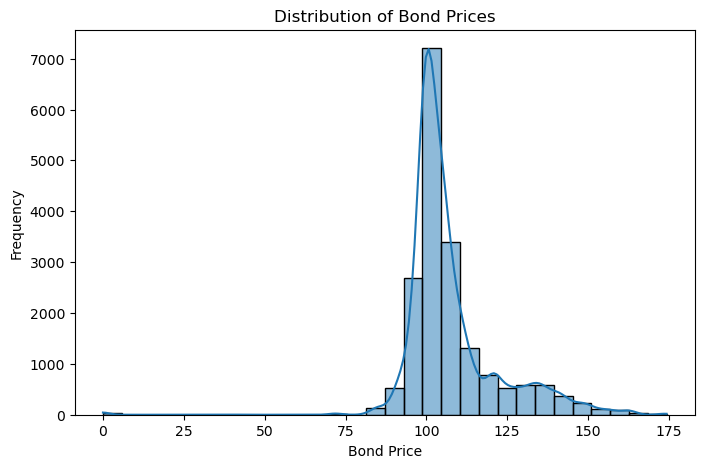

In [65]:
## Step 2.1: Specifics of the dataset.  (5%)

# Shape of dataset
print(f"Shape of dataset: {df.shape}\n")

# Column names
print("Columns (Features):")
print(df.columns.tolist(), "\n")

# Data types
print("Data types:")
print(df.dtypes, "\n")

# Statistics for 'Price' feature
if 'Price' in df.columns:
    print("Statistics for 'Price':")
    print(df['Price'].describe(), "\n")

    # Plot the 'Price' feature
    plt.figure(figsize=(8,5))
    sns.histplot(df['Price'], bins=30, kde=True)
    plt.title("Distribution of Bond Prices")
    plt.xlabel("Bond Price")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("Price column not found - please check dataset columns.\n")


In [66]:
## Step 2.2: Data Cleaning: Remove features with unique values for each row in the dataset. (10%)

unique_per_row = [col for col in df.columns if df[col].is_unique]
print("Features with unique values for each row:")
print(unique_per_row, "\n")

df = df.drop(columns=unique_per_row)
print(f"Remaining features after removal: {df.shape[1]} columns\n")

Features with unique values for each row:
[] 

Remaining features after removal: 27 columns



In [67]:
## Step 2.3: Data Cleaning: Remove features with one unique value for the entire dataset. (10%)

one_value_features = [col for col in df.columns if df[col].nunique() == 1]
print("Features with only one unique value:")
print(one_value_features, "\n")

df = df.drop(columns=one_value_features)
print(f"Remaining features after removal: {df.shape[1]} columns\n")

Features with only one unique value:
['NoRelatedSym', 'SymbolSfx', 'SecurityIDSource', 'Currency', 'OrdType', 'PriceType', 'NoPartIDs', 'PartyID', 'PartyIDSource', 'PartyRole', 'OrdSubType'] 

Remaining features after removal: 16 columns



In [68]:
## Step 2.4: Data Cleaning: Remove records with null (NAN) values. (10%)

print("Number of null values per feature:")
print(df.isnull().sum(), "\n")

Number of null values per feature:
Symbol                  0
SecurityID          13959
SecurityType            0
MaturityDate            0
IssueDate               0
Side                    0
OrderQty                0
SettlDate               0
TransactTime            0
Price                1308
Yield                1297
DealerID                0
DealerTraderID       1055
CustomerTraderID        0
CustomerID              0
DealerCount             0
dtype: int64 



In [69]:
# Remove rows containing any NaN values

df = df.dropna()
print(f"Dataset shape after removing NaN rows: {df.shape}\n")

Dataset shape after removing NaN rows: (5685, 16)



In [70]:
## Step 2.5: Data Transformation: Convert all non-numeric features to numeric. (10%)

# Identifying non-numeric columns
non_numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Non-numeric features:")
print(non_numeric_cols, "\n")


Non-numeric features:
['Symbol', 'SecurityType', 'MaturityDate', 'IssueDate', 'Side', 'SettlDate', 'TransactTime'] 



In [71]:
# Converting categorical columns to numeric using one-hot encoding
df = pd.get_dummies(df, columns=non_numeric_cols, drop_first=True)

print(f"Dataset shape after encoding: {df.shape}")
print("All non-numeric features have been converted to numeric.\n")

Dataset shape after encoding: (5685, 2541)
All non-numeric features have been converted to numeric.



In [72]:
# Final Check

print("Final dataset info summary:")
print(df.info())

Final dataset info summary:
<class 'pandas.core.frame.DataFrame'>
Index: 5685 entries, 6204 to 19999
Columns: 2541 entries, SecurityID to TransactTime_21:57:41
dtypes: bool(2532), float64(4), int64(5)
memory usage: 14.2 MB
None


# Step 3: Model Training and Testing.  (20%)

In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor   # Step 3.1 (Supervised Regression)
from sklearn import metrics

In [87]:
df.shape

(5685, 2541)

In [89]:
df.head(10)

,SecurityID,OrderQty,Price,Yield,DealerID,DealerTraderID,CustomerTraderID,CustomerID,DealerCount,Symbol_013051DB0,...,TransactTime_21:48:21,TransactTime_21:48:41,TransactTime_21:50:04,TransactTime_21:52:51,TransactTime_21:54:57,TransactTime_21:55:51,TransactTime_21:56:30,TransactTime_21:57:33,TransactTime_21:57:36,TransactTime_21:57:41
6204,1657312.0,1000000,111.140,2.243,334,113683.0,11570,454,4,False,...,False,False,False,False,False,False,False,False,False,False
6205,1657312.0,1000000,111.220,2.240,335,114347.0,11570,454,4,False,...,False,False,False,False,False,False,False,False,False,False
6206,1657313.0,5000000,99.760,1.881,323,118599.0,6753,204,1,False,...,False,False,False,False,False,False,False,False,False,False
6207,1657317.0,1250000,111.198,2.241,321,7177.0,6687,178,4,False,...,False,False,False,False,False,False,False,False,False,False
6208,1657317.0,1250000,111.130,2.244,327,7687.0,6687,178,4,False,...,False,False,False,False,False,False,False,False,False,False
6209,1657317.0,1250000,111.190,2.241,334,113683.0,6687,178,4,False,...,False,False,False,False,False,False,False,False,False,False
6210,1657317.0,1250000,111.300,2.236,337,5168.0,6687,178,4,False,...,False,False,False,False,False,False,False,False,False,False
6211,1657324.0,1250000,111.180,2.241,321,7177.0,6687,178,4,False,...,False,False,False,False,False,False,False,False,False,False
6212,1657324.0,1250000,111.130,2.244,327,7687.0,6687,178,4,False,...,False,False,False,False,False,False,False,False,False,False
6213,1657324.0,1250000,111.150,2.243,334,113683.0,6687,178,4,False,...,False,False,False,False,False,False,False,False,False,False


## Step 3.1: Select and Import a ML Algorithm. (5%)
<span style="color:red">
    TODO: Based on your rationale provided in Step 1, import one of the following algorithms:
    <ul> 
    <li>for Supervised Classification ML use <b>'from sklearn.ensemble import RandomForestClassifier'</b></li>
    <li>for Supervised Regression ML use <b>'from sklearn.ensemble import RandomForestRegressor'</b></li>
    <li>for Unsupervised ML use <b>'from sklearn.cluster import KMeans'</b></li>
    </ul>    
</span>

In [91]:
# Removing columns with a unique value per row (IDs, etc.)
unique_per_row = [c for c in df.columns if df[c].is_unique]
df_proc = df.drop(columns=unique_per_row)

# Removing columns with only one unique value overall (uninformative)
one_value_cols = [c for c in df_proc.columns if df_proc[c].nunique() == 1]
df_proc = df_proc.drop(columns=one_value_cols)

# Dropping rows with any NaN
df_proc = df_proc.dropna()

# Ensuring 'Price' exists and split features/target
assert 'Price' in df_proc.columns, "Price column not found after preprocessing."

# Converting non-numeric to numeric (one-hot encode categoricals)
non_numeric = df_proc.select_dtypes(include=['object']).columns.tolist()
df_proc = pd.get_dummies(df_proc, columns=non_numeric, drop_first=True)

## Step 3.2: Train the ML Model. (10%)
<span style="color:red">
    TODO:
    <ul> 
    <li>from the preprocessed dataset, extract 𝑋 - a dataset of all the features but 'Price'</li> 
    <li>from the preprocessed dataset, extract 𝑌  - vector that contains all the values of 'Price'</li>
    <li>slice the dataset: 80% for training and 20% for testing</li>
    <li>create an instance of the selected ML algorithm and train</li>
    </ul>    
</span>

In [94]:
from sklearn.model_selection import train_test_split

In [95]:
# Extracting X (all features except Price) and y (Price)
X = df_proc.drop(columns=['Price'])
y = df_proc['Price']

# Training/testing split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Creating and training the RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

## Step 3.3: Test the ML Model. (5%)
<span style="color:red">
    TODO:
    <ul> 
    <li>use the testing part of the dataset to predic the Bond Prices</li> 
    <li>compute and show the prediction score</li>
    </ul>    
</span>

In [97]:
from sklearn import metrics

In [98]:
# Predicting on the test set
y_pred = rf.predict(X_test)

# Computing evaluation metrics
r2 = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = metrics.mean_squared_error(y_test, y_pred, squared=False)

print("=== RandomForestRegressor: Test Performance ===")
print(f"R^2 score: {r2:.4f}")
print(f"MAE:       {mae:.4f}")
print(f"RMSE:      {rmse:.4f}")

=== RandomForestRegressor: Test Performance ===
R^2 score: 0.9712
MAE:       0.8308
RMSE:      2.5249


C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [99]:
# Note:
# I acknowledge that the FutureWarning about 'squared' in mean_squared_error is expected.
# It does not affect results — it's only a notice that in future scikit-learn versions
# I should use 'root_mean_squared_error()' instead. 

# Step 4: Model Optimization.  (30%)

Enhance the accuracy of your machine learning model by djusting the hyperparameters in order to minimize the cost (loss) function. Use the Grid Search technique.

In [101]:
from sklearn.model_selection import GridSearchCV

In [102]:
# dropping columns with unique values per row (IDs, etc.)
unique_per_row = [c for c in df.columns if df[c].is_unique]
df_opt = df.drop(columns=unique_per_row)

# dropping columns with a single value overall (uninformative)
one_value_cols = [c for c in df_opt.columns if df_opt[c].nunique() == 1]
df_opt = df_opt.drop(columns=one_value_cols)

# dropping rows with NaNs
df_opt = df_opt.dropna()

# safety check for target
assert 'Price' in df_opt.columns, "Price column not found after preprocessing."

# one-hot encode non-numeric features
non_numeric = df_opt.select_dtypes(include=['object']).columns.tolist()
df_opt = pd.get_dummies(df_opt, columns=non_numeric, drop_first=True)

In [104]:
# Training / Testing split

X = df_opt.drop(columns=['Price'])
y = df_opt['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [105]:
# Grid Search over RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parameter grid (balanced for coverage vs. runtime)
param_grid = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 10, 20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}

In [ ]:
# Optimising for lower RMSE (scikit-learn uses negative loss for maximisation)
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("=== Grid Search Completed ===")
print(f"Best CV score (RMSE): {-grid.best_score_:.4f}")
print("Best hyperparameters:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


In [ ]:
# Evaluating best model on the test set

best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("\n=== Best Model: Test Performance ===")
print(f"R^2:  {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")